In [18]:
from pyspark.sql import SparkSession
from pyspark.ml.clustering import KMeansModel

# 1. Iniciamos Spark
spark = SparkSession.builder.appName("S12_Supervisados").getOrCreate()

# 2. CARGAR LOS DATOS (Esto lee el parquet donde guardaste los clusters)
# Asegúrate que esta ruta contenga archivos tipo 'part-00000...'
ruta_datos = "/home/jovyan/work/semanas/Semana 10/modelos/datos_etiquetados_inmobiliaria"
df_clusters = spark.read.parquet(ruta_datos)

print("Datos recuperados:")
df_clusters.show(5)

# 3. CARGAR EL MODELO (Aquí cargamos el "cerebro" para clasificar nuevos datos)
# Nota: La ruta debe ser la misma que usaste en .save()
ruta_modelo = "/home/jovyan/work/semanas/Semana 10/modelos/kmeans_inmobiliaria_v1"
model_recuperado = KMeansModel.load(ruta_modelo)

print("Modelo cargado y listo para nuevas predicciones.")

Datos recuperados:
+--------------------+---------+----+-----------+-----+-------------+-----------+-----------+-----------+--------------+------------+---------------+--------------------+--------------------+----------+
|              titulo|   precio|  m2|dormitorios|banos|ubicacion_cat|quincho_num|terraza_num|piscina_num|lavanderia_num|gimnasio_num|estacionamiento|            features|      scaledFeatures|prediction|
+--------------------+---------+----+-----------+-----+-------------+-----------+-----------+-----------+--------------+------------+---------------+--------------------+--------------------+----------+
|Arriendo departam...| 490000.0|44.0|          2|    1|            1|          0|          0|          1|             0|           0|              1|[490000.0,44.0,2....|[0.04213750140741...|         0|
|          Sin título| 650000.0|74.0|          3|    2|            1|          0|          0|          0|             0|           0|              0|(10,[0,1,2,3,4],[...

In [21]:
from pyspark.sql.functions import col, when
from pyspark.ml.feature import VectorAssembler, StandardScaler, StringIndexer
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# 1. FILTRADO: Eliminamos valores atípicos y nulos críticos en m2 y precios de la IV Región
df_limpio = df_clusters.filter(
    (col("precio") >= 100000) & (col("precio") <= 2500000) &
    (col("m2").isNotNull()) & (col("m2") > 0) & (col("m2") <= 400)
)

# 2. ASEGURAR FORMATO: Convertimos las amenidades a entero
columnas_amenidades = ["gimnasio_num", "lavanderia_num", "piscina_num", "quincho_num", "terraza_num", "estacionamiento"]
for c in columnas_amenidades:
    df_limpio = df_limpio.withColumn(c, col(c).cast("int"))

# 3. TRATAMIENTO DE NULOS: Aplicamos fillna en el subset de amenidades
df_limpio = df_limpio.fillna(0, subset=columnas_amenidades)

# 4. INDEXACIÓN DE CLASES Y LIMPIEZA DE COLUMNA FANTASMA
indexer = StringIndexer(inputCol="prediction", outputCol="label_index")
df_indexado = indexer.fit(df_limpio).transform(df_limpio)
df_indexado = df_indexado.drop("prediction")

# 5. ENSAMBLADO: Unimos características base y amenidades extras
input_cols = ["m2", "dormitorios", "banos"] + columnas_amenidades
assembler = VectorAssembler(inputCols=input_cols, outputCol="features_supervisadas", handleInvalid="skip")
df_ensamblado = assembler.transform(df_indexado)

# 6. ESCALADO: Obligatorio por la diferencia de magnitudes
scaler = StandardScaler(inputCol="features_supervisadas", outputCol="scaledFeatures_supervisadas")
scaler_model = scaler.fit(df_ensamblado)
df_final = scaler_model.transform(df_ensamblado)

# 7. DIVISIÓN DE DATOS (70% entrenamiento, 30% prueba)
train_data, test_data = df_final.randomSplit([0.7, 0.3], seed=42)

# 8. ENTRENAMIENTO DEL ÁRBOL DE DECISIÓN
dt = DecisionTreeClassifier(featuresCol="scaledFeatures_supervisadas", labelCol="label_index", maxDepth=5, seed=42)
dt_model = dt.fit(train_data)

# 9. PREDICCIONES Y EVALUACIÓN
# Ahora sí, Spark creará su propia columna 'prediction' sin problemas
predictions = dt_model.transform(test_data)

evaluator = MulticlassClassificationEvaluator(labelCol="label_index", predictionCol="prediction", metricName="accuracy")
accuracy = evaluator.evaluate(predictions)

print("==================================================")
print(" RESULTADOS DE CLASIFICACIÓN (CON AMENIDADES) ")
print("==================================================")
print(f"Precisión del Árbol de Decisión (Accuracy): {accuracy * 100:.2f}%")
print("==================================================")

# 10. VISUALIZAMOS MUESTRA CON AJUSTE DE TÍTULOS VACÍOS
predictions = predictions.withColumn(
    "titulo_visual", 
    when((col("titulo") == "") | col("titulo").isNull(), "Sin título").otherwise(col("titulo"))
)
print("\n=== PREDICCIONES: TÍTULO, ETIQUETA, PREDICCIÓN Y PROBABILIDAD ===")
predictions.select("titulo_visual", "label_index", "prediction", "probability").show(10, truncate=False)

# 11. REGLAS LÓGICAS EN TEXTO
print("\n=== ESTRUCTURA LÓGICA DEL ÁRBOL ===")
print(dt_model.toDebugString)

 RESULTADOS DE CLASIFICACIÓN (CON AMENIDADES) 
Precisión del Árbol de Decisión (Accuracy): 88.42%

=== PREDICCIONES: TÍTULO, ETIQUETA, PREDICCIÓN Y PROBABILIDAD ===
+----------------------------------------------------------+-----------+----------+-------------------+
|titulo_visual                                             |label_index|prediction|probability        |
+----------------------------------------------------------+-----------+----------+-------------------+
|3d/1b Estacionamiento, Bodega Y Gasto Común Incluido      |0.0        |0.0       |[1.0,0.0,0.0]      |
|AMOBLADO DE MARZO A DICIEMBRE, CONDOMINIO PLAYA HERRRADURA|2.0        |1.0       |[0.0,0.6125,0.3875]|
|AQUA RESORT ARRIENDO MARZO DICIEMBRE LA SERENA            |2.0        |2.0       |[0.0,0.0,1.0]      |
|AQUA RESORT ARRIENDO MARZO DICIEMBRE LA SERENA            |2.0        |2.0       |[0.0,0.0,1.0]      |
|ARRIENDO AÑO CORRIDO  PUERTAS DEL MAR, LA SERENA          |1.0        |2.0       |[0.0,0.4,0.6]      |
|AR

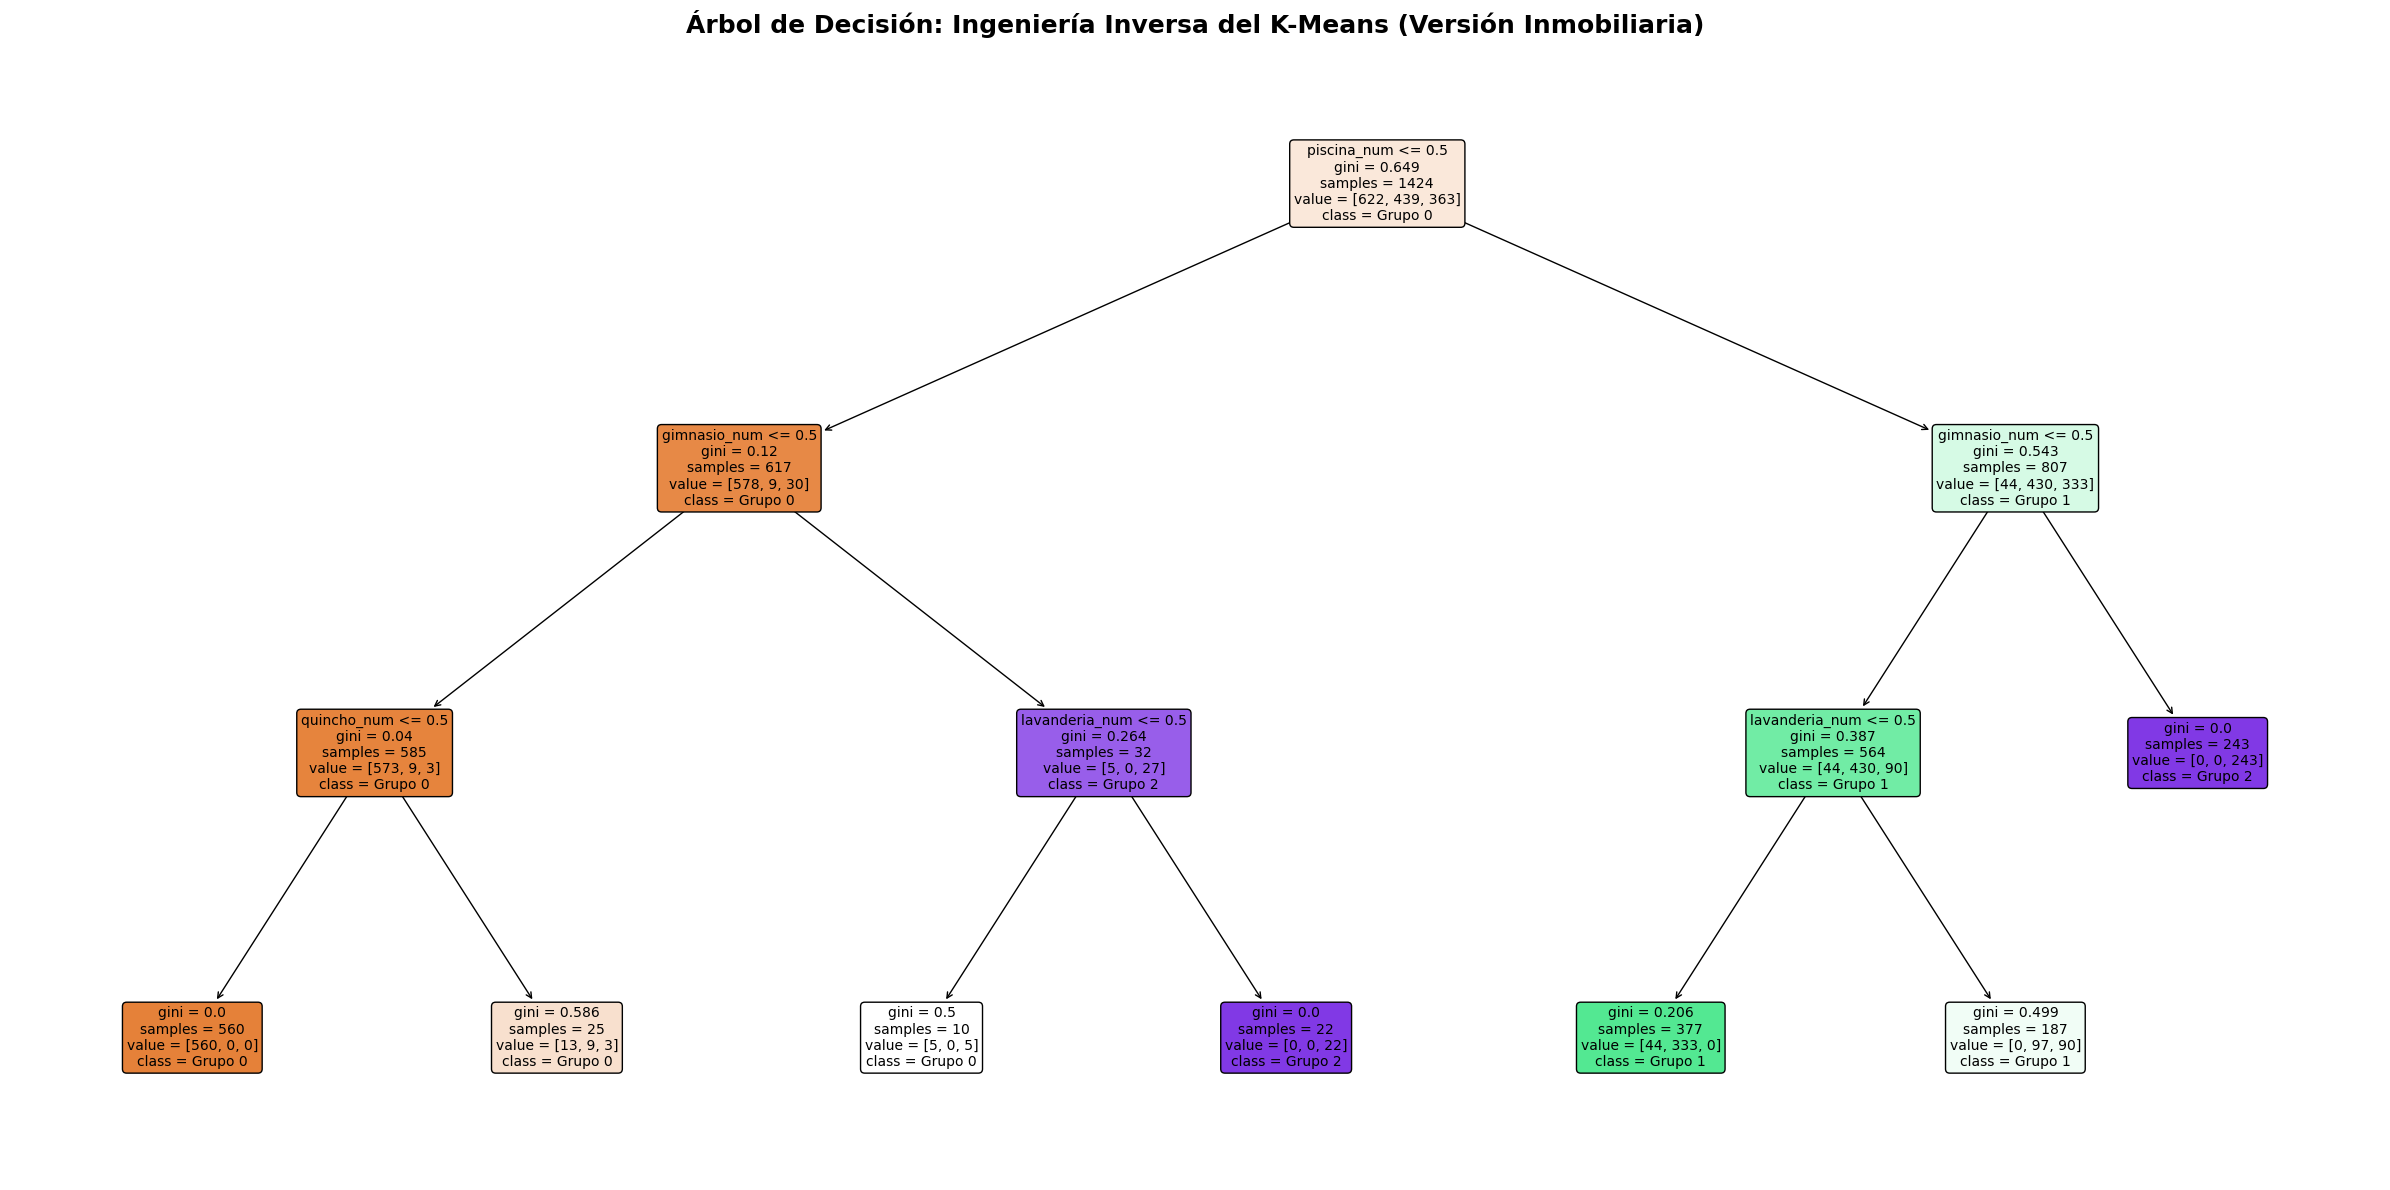

In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.tree import plot_tree
from sklearn.tree import DecisionTreeClassifier as SklearnClassifier

# 1. Convertimos una muestra de nuestro DataFrame indexado de Spark a Pandas
df_pandas = df_indexado.select(*(input_cols + ["label_index"])).toPandas()

# 2. Separamos las características (X) y la etiqueta (y)
X_muestra = df_pandas[input_cols]
y_muestra = df_pandas["label_index"]

# 3. Entrenamos el modelo de Scikit-Learn para renderizado gráfico
sk_dt = SklearnClassifier(max_depth=3, random_state=42)
sk_dt.fit(X_muestra, y_muestra)

# 4. Configurar nombres dinámicos de los 5 clusters
nombres_clases = [f"Grupo {int(c)}" for c in sorted(y_muestra.unique())]

# 5. Dibujamos el árbol de forma visual
plt.figure(figsize=(24, 12), dpi=100)
plot_tree(
    sk_dt,
    feature_names=input_cols,
    class_names=nombres_clases,
    filled=True,      
    rounded=True,     
    fontsize=10       
)
plt.title("Árbol de Decisión: Ingeniería Inversa del K-Means (Versión Inmobiliaria)", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
from pyspark.ml.classification import RandomForestClassifier, LinearSVC, LogisticRegression, OneVsRest

feat_col = "scaledFeatures_supervisadas"

# Función automatizada para entrenar y evaluar
def entrenar_y_evaluar(modelo, nombre_modelo, train, test):
    modelo_fit = modelo.fit(train)
    preds = modelo_fit.transform(test)
    acc = evaluator.evaluate(preds)
    print(f"Accuracy {nombre_modelo}: {acc * 100:.2f}%")
    return preds

print("=== INICIANDO ENTRENAMIENTO MULTI-MODELO ===")

# Modelo 1: Random Forest (Bosques Aleatorios)
rf = RandomForestClassifier(featuresCol=feat_col, labelCol="label_index", numTrees=20, seed=42)
rf_preds = entrenar_y_evaluar(rf, "Random Forest", train_data, test_data)

# Modelo 2: SVM (Máquina de Vectores de Soporte usando OneVsRest)
svm_binario = LinearSVC(featuresCol=feat_col, labelCol="label_index", maxIter=10)
ovr_svm = OneVsRest(classifier=svm_binario, labelCol="label_index", featuresCol=feat_col)
svm_preds = entrenar_y_evaluar(ovr_svm, "SVM (OneVsRest)", train_data, test_data)

# Modelo 3: Regresión Logística Multinomial
lr = LogisticRegression(featuresCol=feat_col, labelCol="label_index", maxIter=10, family="multinomial")
lr_preds = entrenar_y_evaluar(lr, "Regresión Logística", train_data, test_data)

# Tabla Comparativa de Resultados Finales
print("\n==================================================")
print(" RESULTADOS DE MODELOS SUPERVISADOS (SEMANA 12) ")
print("==================================================")
print(f"1. Random Forest Accuracy:      {evaluator.evaluate(rf_preds) * 100:.2f}%")
print(f"2. SVM (OneVsRest) Accuracy:    {evaluator.evaluate(svm_preds) * 100:.2f}%")
print(f"3. Regresión Logística Accuracy:{evaluator.evaluate(lr_preds) * 100:.2f}%")
print("==================================================")

=== INICIANDO ENTRENAMIENTO MULTI-MODELO ===
Accuracy Random Forest: 69.37%
Accuracy SVM (OneVsRest): 69.37%
Accuracy Regresión Logística: 69.57%

 RESULTADOS DE MODELOS SUPERVISADOS (SEMANA 12) 
1. Random Forest Accuracy:      69.37%
2. SVM (OneVsRest) Accuracy:    69.37%
3. Regresión Logística Accuracy:69.57%


In [23]:
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator

# 1. PREPARACIÓN: Renombramos 'precio' a 'label' y normalizamos campos de texto
df_prep = df_clusters.withColumnRenamed("precio", "label") \
                     .withColumn("titulo", when((col("titulo") == "") | col("titulo").isNull(), "Sin título").otherwise(col("titulo")))

import pyspark.sql.functions as F

print("=== AUDITORÍA DE AMENIDADES ===")
print("¿Cuántas propiedades tienen realmente cada amenidad?")

# Sumamos todos los 1s de cada columna para ver si hay alguna propiedad que la tenga
df_prep.select(
    *[F.sum(col(c)).alias(f"Total_con_{c}") for c in columnas_amenidades]
).show()

# Aseguramos formato numérico e imputamos nulos en el subset de regresión
for c in columnas_amenidades:
    df_prep = df_prep.withColumn(c, col(c).cast("int"))
df_prep = df_prep.fillna(0, subset=columnas_amenidades)

# 2. VECTORASSEMBLER DE REGRESIÓN: Contiene las 9 variables independientes (EXCLUYE EL PRECIO)
input_cols_reg = ["dormitorios", "banos", "m2"] + columnas_amenidades
assembler_regresion = VectorAssembler(inputCols=input_cols_reg, outputCol="features_regresion")
df_vector_reg = assembler_regresion.transform(df_prep)

# 3. ESCALADO DE CARACTERÍSTICAS DE REGRESIÓN
scaler_reg = StandardScaler(inputCol="features_regresion", outputCol="scaledFeatures_regresion")
df_para_regresion = scaler_reg.fit(df_vector_reg).transform(df_vector_reg)

# 4. DESCARTE DE COLUMNAS SOBRANTES Y FILTRADO DE OUTLIERS CRÍTICOS
columnas_a_borrar = ["prediction", "enlace", "imagen", "ubicacion", "fecha_extraccion", "responsable", "features_regresion"]
df_para_regresion = df_para_regresion.drop(*columnas_a_borrar)

df_regresion_limpio = df_para_regresion.filter(
    (col("label") <= 2500000) & (col("label") >= 100000) &
    (col("m2").isNotNull()) & (col("m2") <= 400)
)

# 5. DIVISIÓN DE DATOS (70/30)
train_reg, test_reg = df_regresion_limpio.randomSplit([0.7, 0.3], seed=42)
print(f"Datos limpios para regresión - Entrenamiento: {train_reg.count()} | Prueba: {test_reg.count()}")

# 6. CONFIGURACIÓN Y ENTRENAMIENTO
lr_regresion = LinearRegression(featuresCol="scaledFeatures_regresion", labelCol="label", maxIter=10)
print("Entrenando el modelo multivariable de Regresión Lineal...")
lr_reg_model = lr_regresion.fit(train_reg)
predictions_regresion = lr_reg_model.transform(test_reg)

# 7. MUESTRA COMPARATIVA DE RESULTADOS
print("\n=== COMPARATIVA: PRECIO REAL VS PRECIO PREDICHO ===")
predictions_regresion.select("titulo", "label", "prediction").show(10, truncate=False)

# 8. EVALUACIÓN MEDIANTE MÉTRICAS (R2 Y RMSE)
evaluator_r2 = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="r2")
evaluator_rmse = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="rmse")

r2 = evaluator_r2.evaluate(predictions_regresion)
rmse = evaluator_rmse.evaluate(predictions_regresion)

print("==================================================")
print(" EVALUACIÓN DE LA REGRESIÓN INMOBILIARIA ")
print("==================================================")
print(f"R² (Poder predictivo del modelo): {r2 * 100:.2f}%")
print(f"RMSE (Margen de error promedio en valor): {rmse:,.2f}")
print("==================================================")

# 9. EXTRACCIÓN DE COEFICIENTES 
print(f"\nIntersección (Precio base estimado si todo fuera cero): {lr_reg_model.intercept:.4f}")
print("\nCoeficientes (Peso relativo de cada variable en el precio final):")
for i, feature in enumerate(input_cols_reg):
    coeficiente = lr_reg_model.coefficients[i]
    print(f"Coeficiente de '{feature}': {coeficiente:.4f}")

=== AUDITORÍA DE AMENIDADES ===
¿Cuántas propiedades tienen realmente cada amenidad?
+----------------------+------------------------+---------------------+---------------------+---------------------+-------------------------+
|Total_con_gimnasio_num|Total_con_lavanderia_num|Total_con_piscina_num|Total_con_quincho_num|Total_con_terraza_num|Total_con_estacionamiento|
+----------------------+------------------------+---------------------+---------------------+---------------------+-------------------------+
|                   378|                     526|                 1176|                  843|                 1009|                     1827|
+----------------------+------------------------+---------------------+---------------------+---------------------+-------------------------+

Datos limpios para regresión - Entrenamiento: 1287 | Prueba: 483
Entrenando el modelo multivariable de Regresión Lineal...

=== COMPARATIVA: PRECIO REAL VS PRECIO PREDICHO ===
+---------------------------